In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [6]:
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df = df.dropna(subset=['CustomerID'])

df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(5225)

In [11]:
df = df.drop_duplicates()

df.shape

(401604, 8)

In [12]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [13]:
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [14]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [15]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [17]:
rfm.describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,92.047118,5.075480,1893.531433
std,100.765435,9.338754,8218.696204
min,1.000000,1.000000,-4287.630000
25%,17.000000,1.000000,291.795000
50%,50.000000,3.000000,644.070000
75%,143.000000,5.000000,1608.335000
max,374.000000,248.000000,279489.020000


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

rfm_scaled[:5]

ModuleNotFoundError: No module named 'sklearn'

In [19]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 1.6 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/8.4 MB 1.6 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.4 MB 1.7 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/8.4 MB 1.8 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.4 MB 1.8 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.4 MB 1.9 MB/s eta 0:00:04
   --------------- ------------------------ 3.1/8.4 MB 1.9 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.4 MB 1.9 MB/s eta 0:00:03
   ------------------ --------------------- 3.9/8.4 MB 1.9 MB/s eta 0:00:03
   --------------------- ---------------

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

rfm_scaled[:5]

array([[ 2.32202285, -0.32936215, -0.23041952],
       [-0.89373323,  0.20610242,  0.29405454],
       [-0.1691956 , -0.11517632, -0.01171748],
       [-0.72500529, -0.43645506, -0.01654727],
       [ 2.16322008, -0.43645506, -0.18972715]])

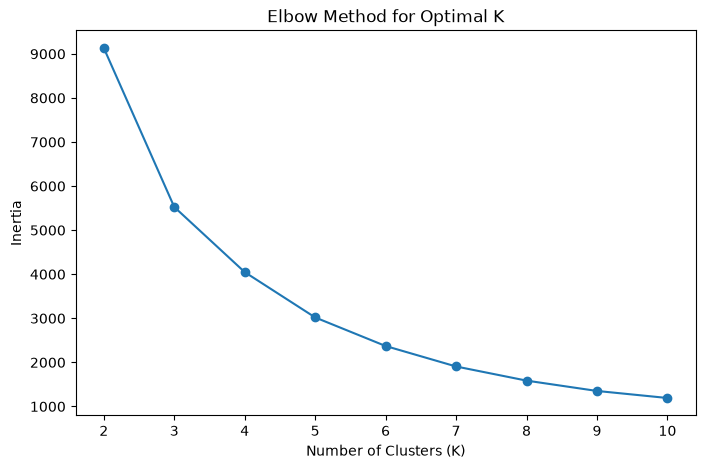

In [21]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [22]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [23]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,44.19,3.89,1177.03
1,249.51,1.80,452.05
2,3.67,64.67,241083.23
3,6.18,88.36,54563.86
4,13.77,20.77,7492.87


In [24]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

cluster_counts

Cluster
0    2957
1    1071
2       3
3      22
4     319
Name: count, dtype: int64

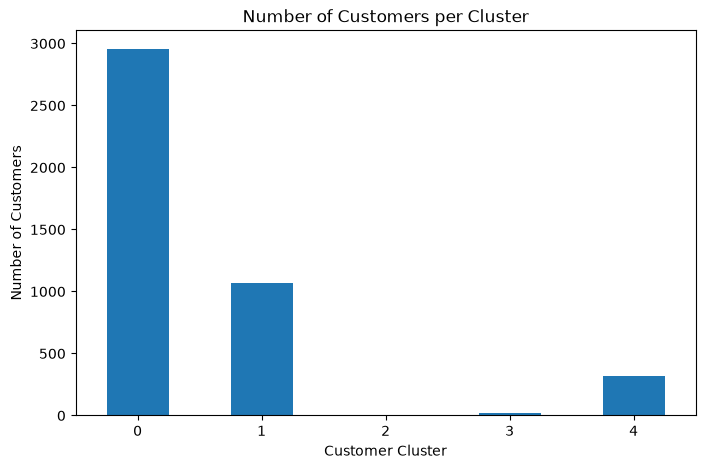

In [25]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')
plt.xticks(rotation=0)
plt.show()

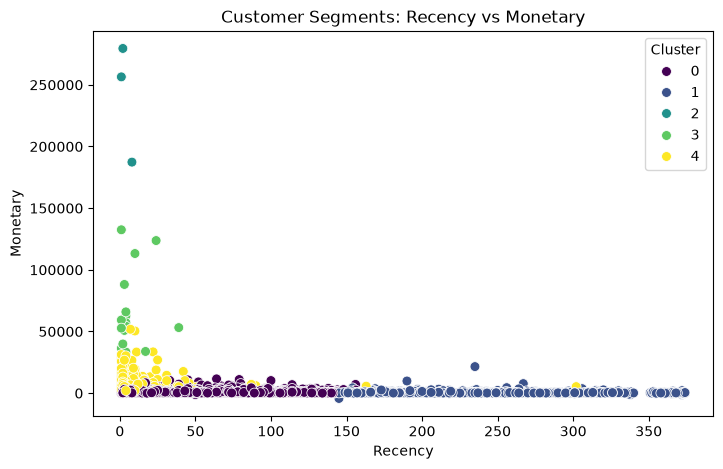

In [26]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=50
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Outputs/elbow_method.png'

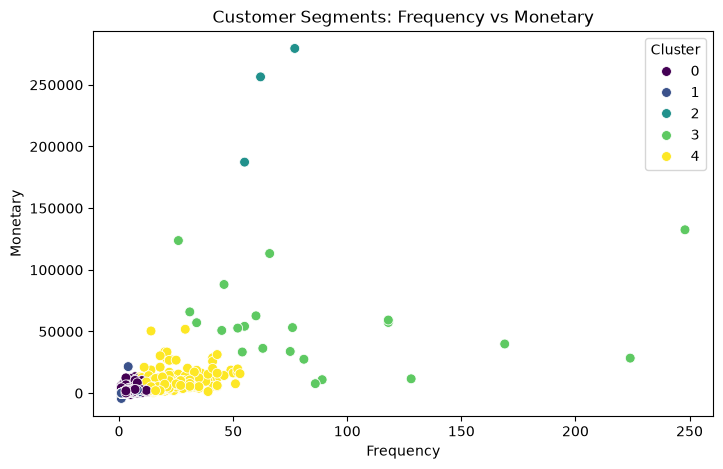

In [37]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=50
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.savefig("Outputs/elbow_method.png",bbox_inches='tight')
plt.show()

In [28]:
print("Average Purchase Value:", round(df['TotalAmount'].mean(), 2))
print("Average Purchase Frequency:", round(rfm['Frequency'].mean(), 2))
print("Average Customer Lifetime Value:", round(rfm['Monetary'].mean(), 2))

Average Purchase Value: 20.61
Average Purchase Frequency: 5.08
Average Customer Lifetime Value: 1893.53


In [29]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [30]:
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,44.19,3.89,1177.03
1,249.51,1.80,452.05
2,3.67,64.67,241083.23
3,6.18,88.36,54563.86
4,13.77,20.77,7492.87


In [31]:
cluster_names = {
    0: 'Regular Customers',
    1: 'At-Risk / Lost Customers',
    2: 'High-Value Customers',
    3: 'Champions / VIP Customers',
    4: 'Loyal Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,2,0.00,1,At-Risk / Lost Customers
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,At-Risk / Lost Customers


In [32]:
segment_profile = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

segment_profile

,Recency,Frequency,Monetary
Segment,,,
At-Risk / Lost Customers,249.51,1.80,452.05
Champions / VIP Customers,6.18,88.36,54563.86
High-Value Customers,3.67,64.67,241083.23
Loyal Customers,13.77,20.77,7492.87
Regular Customers,44.19,3.89,1177.03


## Customer Segment Insights

### 1. Regular Customers
These customers purchase occasionally and have moderate recency and spending.
*Marketing Action:* Use personalized offers, product recommendations, and loyalty incentives to increase purchase frequency.

### 2. At-Risk / Lost Customers
These customers have not purchased recently and have relatively low purchase frequency and spending.
*Marketing Action:* Send re-engagement campaigns, special discounts, and limited-time offers to encourage them to return.

### 3. High-Value Customers
These customers have very recent purchases and extremely high spending.
*Marketing Action:* Provide premium offers, personalized recommendations, early access to new products, and VIP benefits.

### 4. Champions / VIP Customers
These are the most frequent and highly valuable customers with very recent purchases.
*Marketing Action:* Reward them with exclusive loyalty benefits, referral programs, VIP support, and early access to products.

### 5. Loyal Customers
These customers purchase frequently and generate good revenue while remaining recently active.
*Marketing Action:* Strengthen loyalty through membership rewards, personalized promotions, and cross-selling opportunities.

## Overall Business Insight
Customer segmentation using RFM analysis and K-Means clustering helps the business understand different
customer purchasing behaviours.
The company can use these segments to create targeted marketing campaigns, improve customer retention, and focus resources on high-value customers.

In [35]:
segment_counts = rfm['Segment'].value_counts()

segment_counts

Segment
Regular Customers            2957
At-Risk / Lost Customers     1071
Loyal Customers               319
Champions / VIP Customers      22
High-Value Customers            3
Name: count, dtype: int64

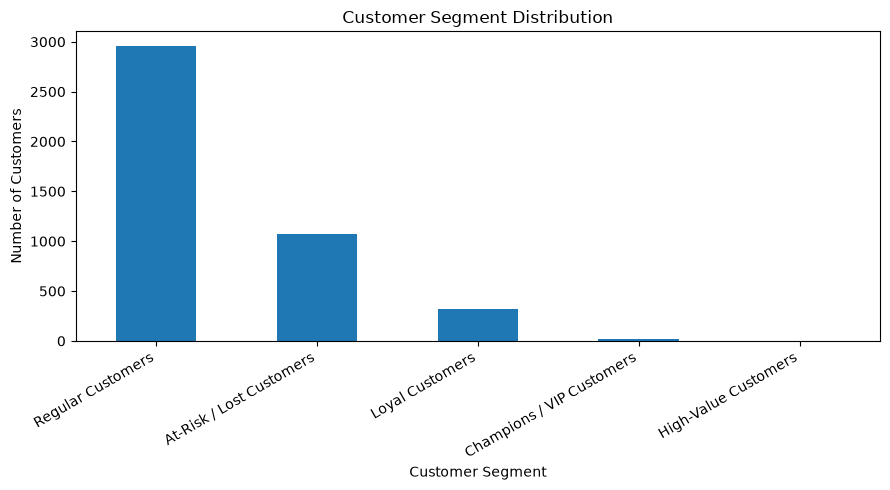

In [36]:
plt.figure(figsize=(9, 5))

segment_counts.plot(kind='bar')

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Segment Distribution')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Conclusion

The customer segmentation analysis successfully grouped customers based on their purchasing behaviour using RFM (Recency, Frequency, and Monetary) analysis and K-Means clustering.

Five distinct customer segments were identified: Regular Customers, At-Risk / Lost Customers, High-Value Customers, Champions / VIP Customers, and Loyal Customers.

The analysis helps the business understand customer value, identify customers who may need re-engagement, and recognize high-value and loyal customers. These insights can support targeted marketing campaigns, customer retention strategies, personalized promotions, and improved business decision-making.

FileNotFoundError: [Errno 2] No such file or directory: 'Outputs/customers_per_cluster.png'

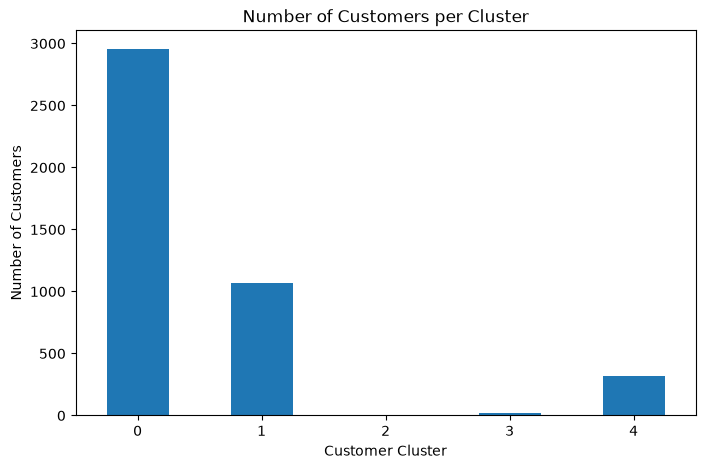

In [38]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')
plt.xticks(rotation=0)

plt.savefig("Outputs/customers_per_cluster.png", bbox_inches='tight')

plt.show()

In [39]:
import os 
os.getcwd()

'C:\\Users\\Bajji\\OIBSIP'

In [40]:
import os

os.makedirs("Outputs", exist_ok=True)

print("Outputs folder created successfully!")

Outputs folder created successfully!


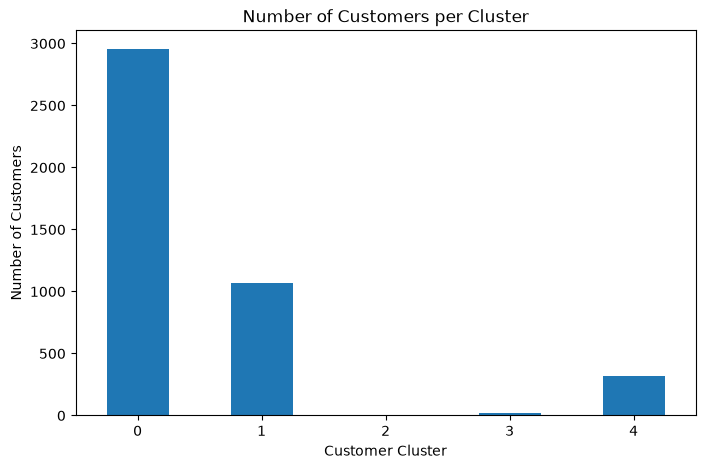

In [41]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')
plt.xticks(rotation=0)

plt.savefig("Outputs/customers_per_cluster.png", bbox_inches='tight')

plt.show()

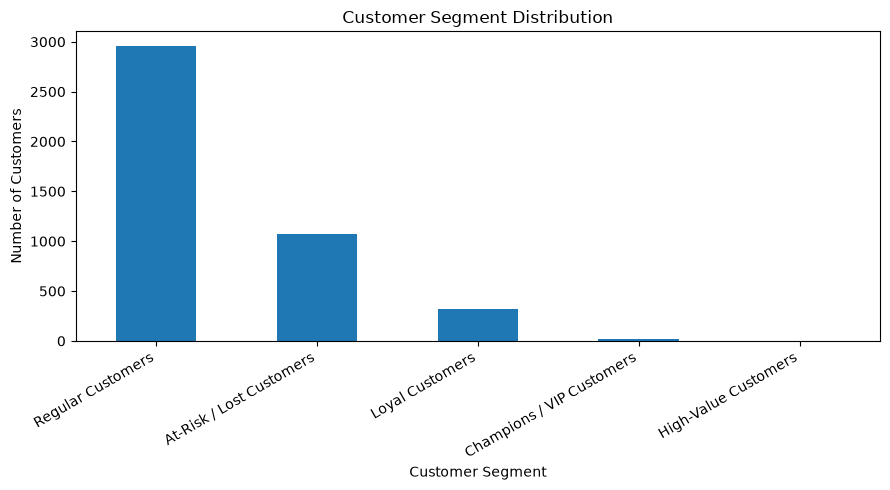

In [42]:
plt.figure(figsize=(9, 5))

segment_counts.plot(kind='bar')

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Segment Distribution')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.savefig("Outputs/customer_segment_distribution.png", bbox_inches='tight')

plt.show()

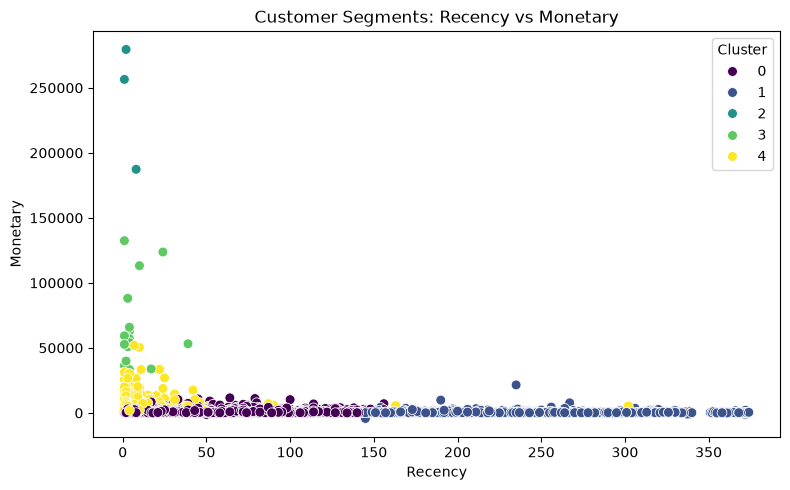

In [43]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=50
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.tight_layout()

plt.savefig("Outputs/recency_vs_monetary.png", bbox_inches='tight')

plt.show()

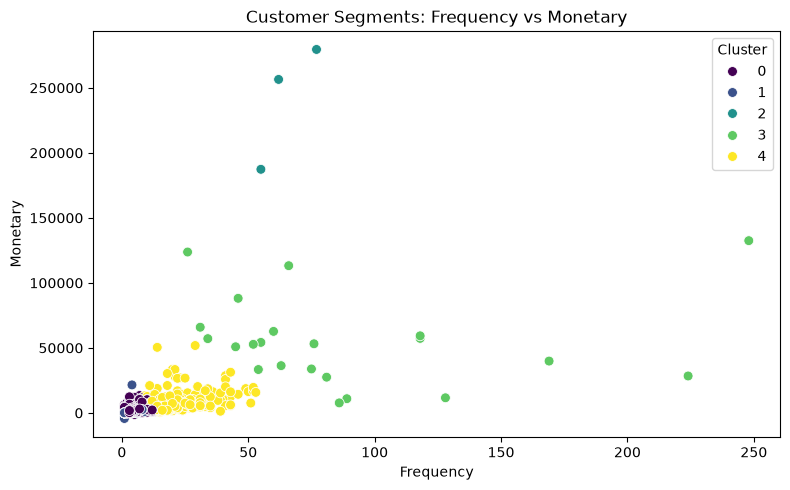

In [44]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=50
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.tight_layout()

plt.savefig("Outputs/frequency_vs_monetary.png", bbox_inches='tight')

plt.show()

In [45]:
import os
print(os.path.abspath("Outputs"))

C:\Users\Bajji\OIBSIP\Outputs


In [46]:
import os

os.makedirs(r"C:\Users\Bajji\Downloads\Data Analytics L1 Customer Segmentation\Outputs", exist_ok=True)

print("Correct Outputs folder is ready!")

Correct Outputs folder is ready!


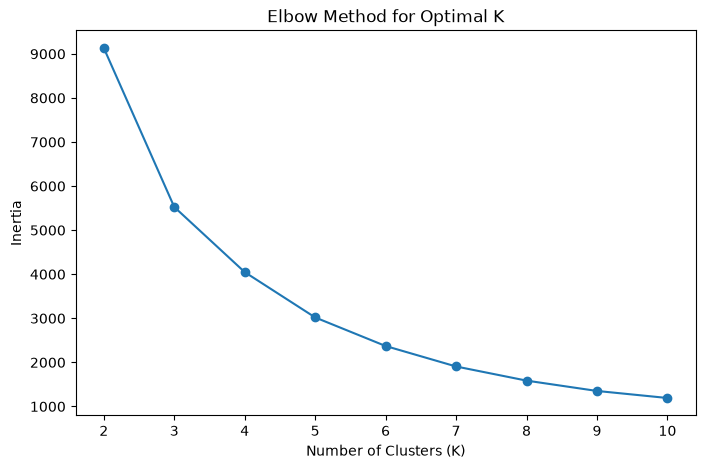

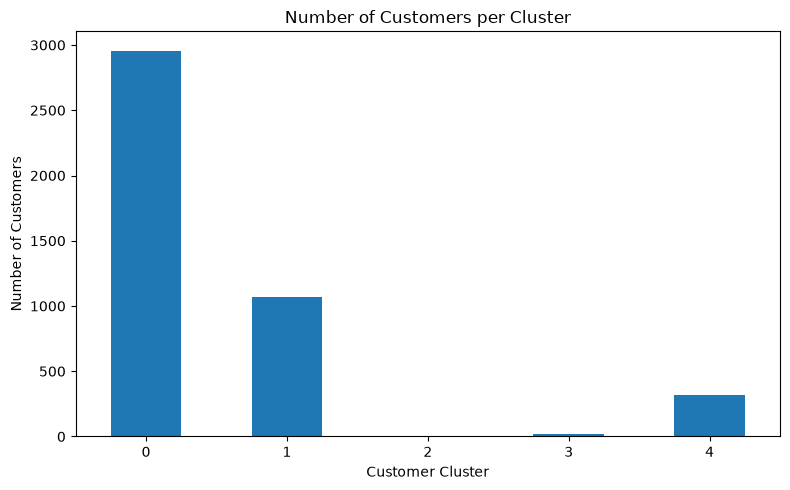

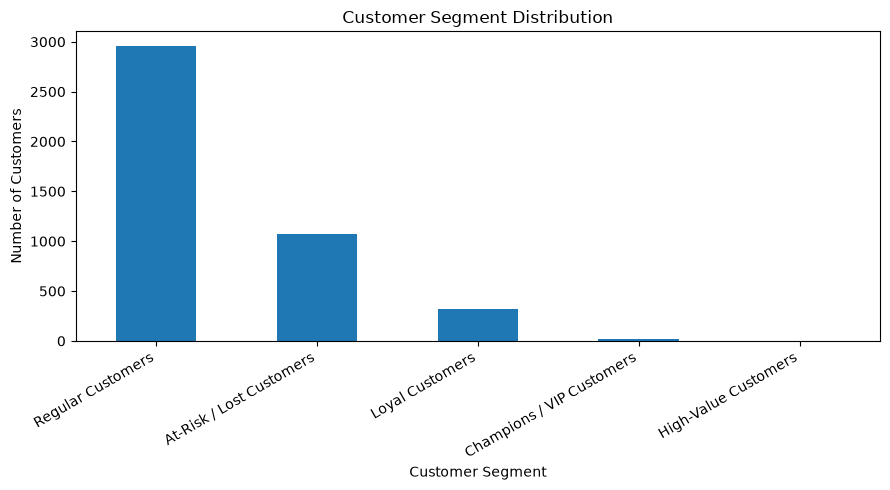

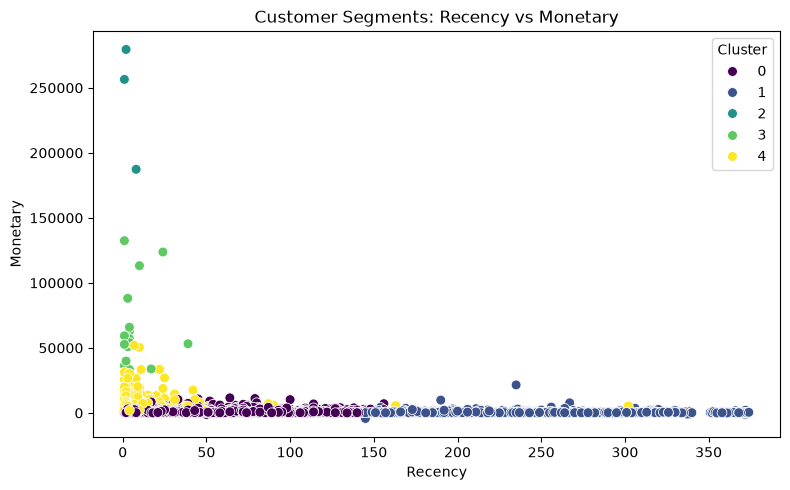

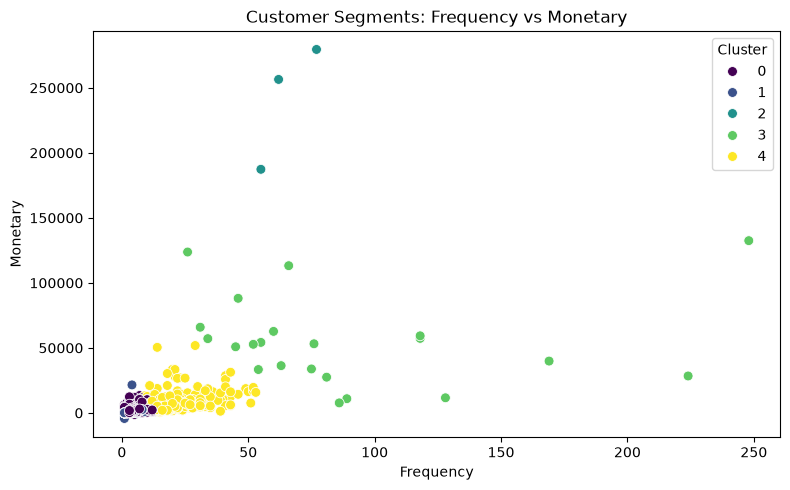

All 5 charts saved successfully!


In [47]:
import os

output_path = r"C:\Users\Bajji\Downloads\Data Analytics L1 Customer Segmentation\Outputs"
os.makedirs(output_path, exist_ok=True)

# 1. Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig(os.path.join(output_path, "elbow_method.png"), bbox_inches='tight')
plt.show()
plt.close()

# 2. Customers per Cluster
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_path, "customers_per_cluster.png"), bbox_inches='tight')
plt.show()
plt.close()

# 3. Customer Segment Distribution
plt.figure(figsize=(9, 5))
segment_counts.plot(kind='bar')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Segment Distribution')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_path, "customer_segment_distribution.png"), bbox_inches='tight')
plt.show()
plt.close()

# 4. Recency vs Monetary
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=50
)
plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig(os.path.join(output_path, "recency_vs_monetary.png"), bbox_inches='tight')
plt.show()
plt.close()

# 5. Frequency vs Monetary
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=50
)
plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig(os.path.join(output_path, "frequency_vs_monetary.png"), bbox_inches='tight')
plt.show()
plt.close()

print("All 5 charts saved successfully!")